In [6]:
!find /content/drive/MyDrive/Colab Notebooks/ -name "02_eda_user_behavior.ipynb"

find: ‘/content/drive/MyDrive/Colab’: No such file or directory
find: ‘Notebooks/’: No such file or directory


In [ ]:
#SETTING
from google.colab import userdata, drive
import os

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Setup Info
GIT_TOKEN = userdata.get("My_Token")
GIT_USERNAME = "Tanior14"
GIT_EMAIL = "thuantan1905@gmail.com"
REPO_OWNER = "nhnminh1409"
GIT_REPO = "instacart-market-basket-analysis"

# Define Source File and Destination Path
SOURCE_PATH = "/content/drive/MyDrive/Colab Notebooks/02_eda_user_behavior.ipynb"
TARGET_DIR = "notebooks"

# 3.Setup Git Repo
%cd /content/
# Fix URL formatting (Remove redundant ://)
PUSH_URL = f"https://{GIT_TOKEN}@github.com/{REPO_OWNER}/{GIT_REPO}.git"

if not os.path.exists(GIT_REPO):
    !git clone {PUSH_URL}
else:
    print("Repo existed!")

%cd {GIT_REPO}
!git config --global user.email "{GIT_EMAIL}"
!git config --global user.name "{GIT_USERNAME}"

!git fetch origin
!git reset --hard origin/main

# 4. Copy files to the specific directory
# Create 'notebooks' directory if not exists
!mkdir -p {TARGET_DIR}

# Move files to 'notebooks' directory
!cp "{SOURCE_PATH}" "{TARGET_DIR}/"

# 5. Deploy code to GitHub repository
!git add .
!git commit -m "feat: complete user behavior EDA and feature engineering" || echo "No changes to commit"
!git push origin main --force


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Repo existed!
/content/instacart-market-basket-analysis
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 340.07 KiB | 6.54 MiB/s, done.
From https://github.com/nhnminh1409/instacart-market-basket-analysis
   3bda486..beda054  main       -> origin/main
HEAD is now at beda054 Build product and user-product features for behavior analysis
[main 10a4258] feat: complete user behavior EDA and feature engineering
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite notebooks/02_eda_user_behavior.ipynb (82%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4),

In [ ]:
# --- SYNC & PUSH ---
!cp "{SOURCE_PATH}" ./notebooks/
!git add .
!git commit -m "feat: complete user behavior EDA and feature engineering" || echo "No changes to commit"
!git push origin main --force


print(f"🚀 Success! Link: https://github.com/{REPO_OWNER}/{GIT_REPO}")



[main 69fb13c] Step 4: Pipeline: Final data splitting and Parquet export
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite notebooks/EDA & Users Features-Tanior.ipynb (82%)
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 959.47 KiB | 7.11 MiB/s, done.
Total 8 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 1 local object.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-

Instacart Market Basket Analysis
## EDA & User Feature Engineering

**Dataset:** `prior_data_cleaned.parquet` — 32M rows of historical purchase data  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
PALETTE = 'Set2'

print('Libraries loaded.')


Libraries loaded.


In [ ]:
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Instacart_Project/'
df = pd.read_parquet(DATA_PATH + 'prior_data_cleaned.parquet')

print(f'Loaded successfully!')
print(f'   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded successfully!
   Shape : 32,432,247 rows × 15 columns
   Memory: 1042.9 MB


In [ ]:
# Quick overview
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32432247 entries, 0 to 32432246
Data columns (total 15 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   user_id                 int32   
 2   eval_set                category
 3   order_number            int8    
 4   order_dow               int8    
 5   order_hour_of_day       int8    
 6   days_since_prior_order  float32 
 7   product_id              int32   
 8   product_name            category
 9   aisle_id                int16   
 10  aisle                   category
 11  department_id           int8    
 12  department              category
 13  add_to_cart_order       int8    
 14  reordered               int8    
dtypes: category(4), float32(1), int16(1), int32(3), int8(6)
memory usage: 991.1 MB


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,product_name,aisle_id,aisle,department_id,department,add_to_cart_order,reordered
0,2,202279,prior,3,5,9,8.0,33120,Organic Egg Whites,86,eggs,16,dairy eggs,1,1
1,2,202279,prior,3,5,9,8.0,28985,Michigan Organic Kale,83,fresh vegetables,4,produce,2,1
2,2,202279,prior,3,5,9,8.0,9327,Garlic Powder,104,spices seasonings,13,pantry,3,0
3,2,202279,prior,3,5,9,8.0,45918,Coconut Butter,19,oils vinegars,13,pantry,4,1
4,2,202279,prior,3,5,9,8.0,30035,Natural Sweetener,17,baking ingredients,13,pantry,5,0


---
## PART 1: EDA — Temporal Behavior (Time Patterns)

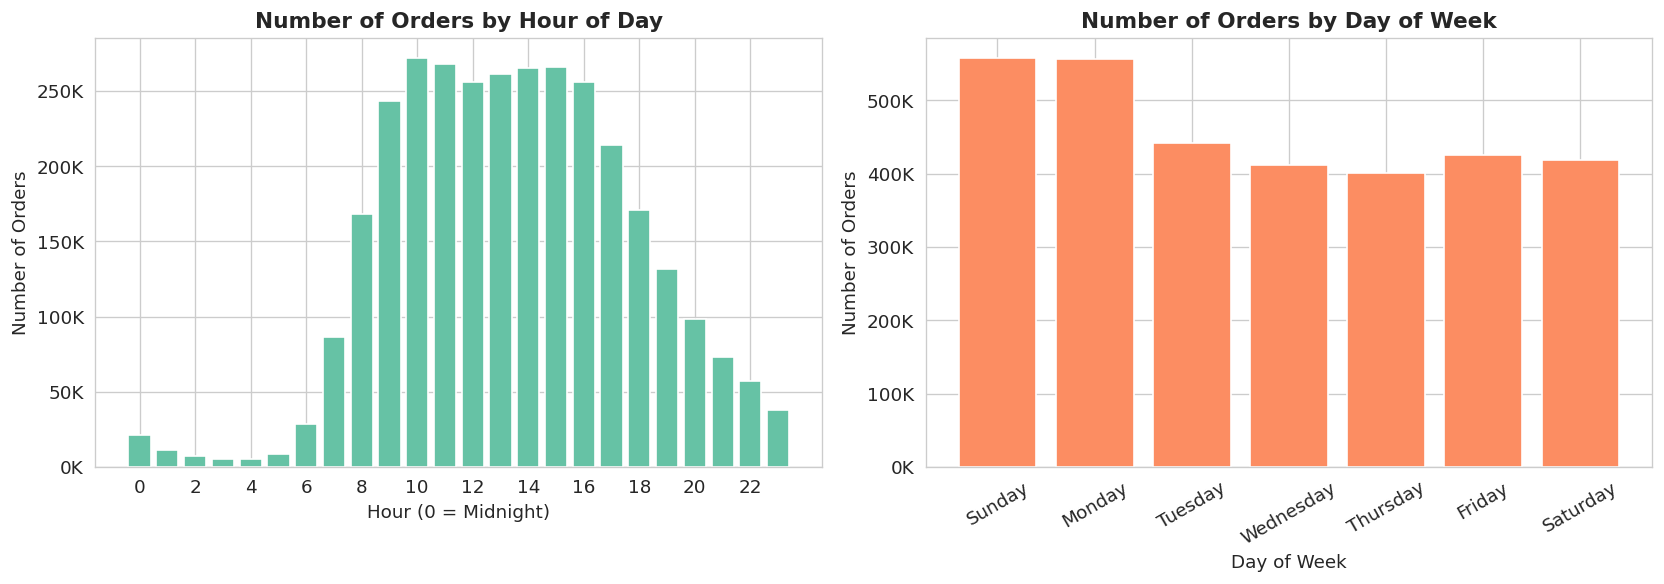

 Peak hour : 10:00
 Peak day  : Sunday


In [ ]:
# *** Orders by Hour of Day
hourly = df.drop_duplicates('order_id').groupby('order_hour_of_day')['order_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour of day
axes[0].bar(hourly.index, hourly.values, color=sns.color_palette(PALETTE)[0])
axes[0].set_title('Number of Orders by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour (0 = Midnight)')
axes[0].set_ylabel('Number of Orders')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[0].set_xticks(range(0, 24, 2))

# Day of week
dow_labels = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
daily = df.drop_duplicates('order_id').groupby('order_dow')['order_id'].count()
axes[1].bar([dow_labels[i] for i in daily.index], daily.values,
            color=sns.color_palette(PALETTE)[1])
axes[1].set_title('Number of Orders by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Orders')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot_temporal_patterns.png', bbox_inches='tight')
plt.show()

peak_hour = hourly.idxmax()
peak_day  = dow_labels[daily.idxmax()]
print(f' Peak hour : {peak_hour}:00')
print(f' Peak day  : {peak_day}')

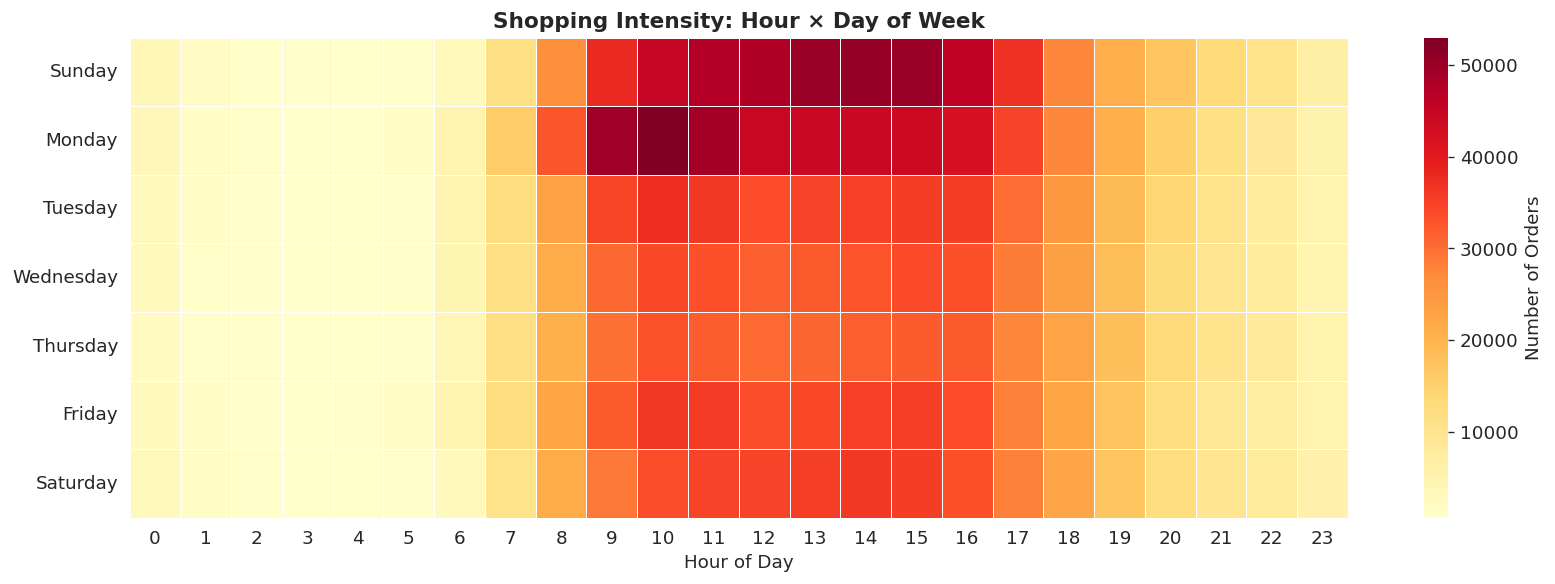

In [ ]:
# Heatmap: Hour vs Day of Week
orders_only = df.drop_duplicates('order_id')
heatmap_data = orders_only.groupby(['order_dow', 'order_hour_of_day'])['order_id'] \
                           .count().unstack(fill_value=0)
heatmap_data.index = [dow_labels[i] for i in heatmap_data.index]

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Number of Orders'})
plt.title('Shopping Intensity: Hour × Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.tight_layout()
plt.savefig('plot_heatmap_hour_dow.png', bbox_inches='tight')
plt.show()

---
## PART 2: EDA — Products & Categories

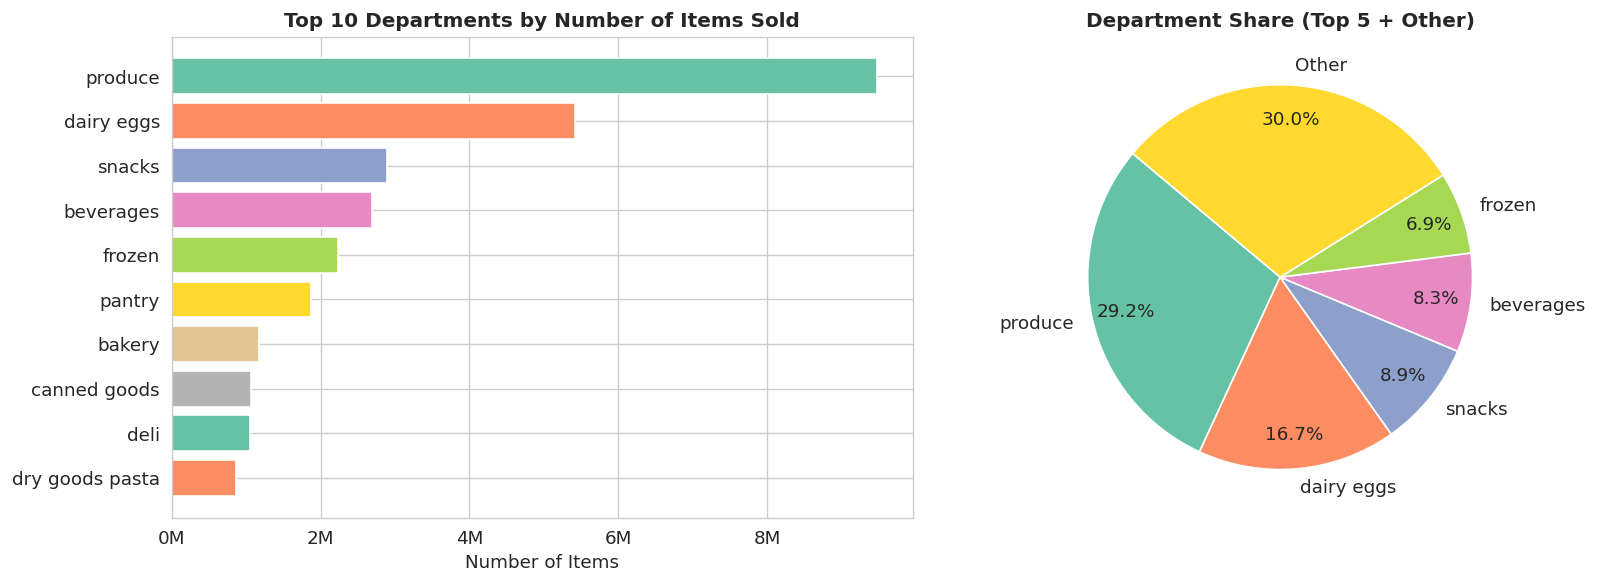

In [ ]:
# *** Top 10 Departments
dept_counts = df.groupby('department')['product_id'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10_dept = dept_counts.head(10)
axes[0].barh(top10_dept.index[::-1], top10_dept.values[::-1],
             color=sns.color_palette(PALETTE, 10)[::-1])
axes[0].set_title('Top 10 Departments by Number of Items Sold', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Items')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))

# Pie chart of department share
top5 = dept_counts.head(5)
other = dept_counts.iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Other': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=sns.color_palette(PALETTE, len(pie_data)),
            startangle=140, pctdistance=0.82)
axes[1].set_title('Department Share (Top 5 + Other)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_department_analysis.png', bbox_inches='tight')
plt.show()

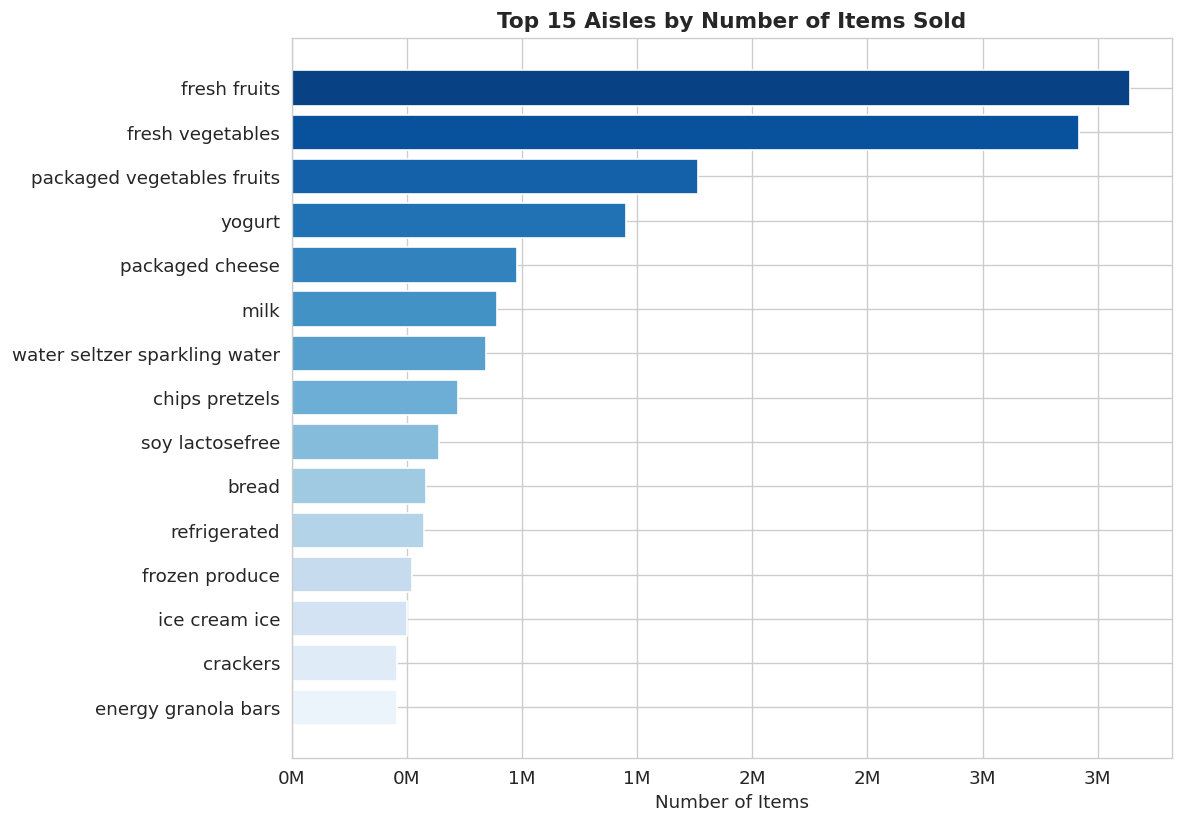

In [ ]:
# *** Top 15 Aisles
aisle_counts = df.groupby('aisle')['product_id'].count().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(range(15), aisle_counts.values, color=sns.color_palette('Blues_r', 15))
plt.yticks(range(15), aisle_counts.index, fontsize=11)
plt.title('Top 15 Aisles by Number of Items Sold', fontsize=13, fontweight='bold')
plt.xlabel('Number of Items')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plot_top_aisles.png', bbox_inches='tight')
plt.show()

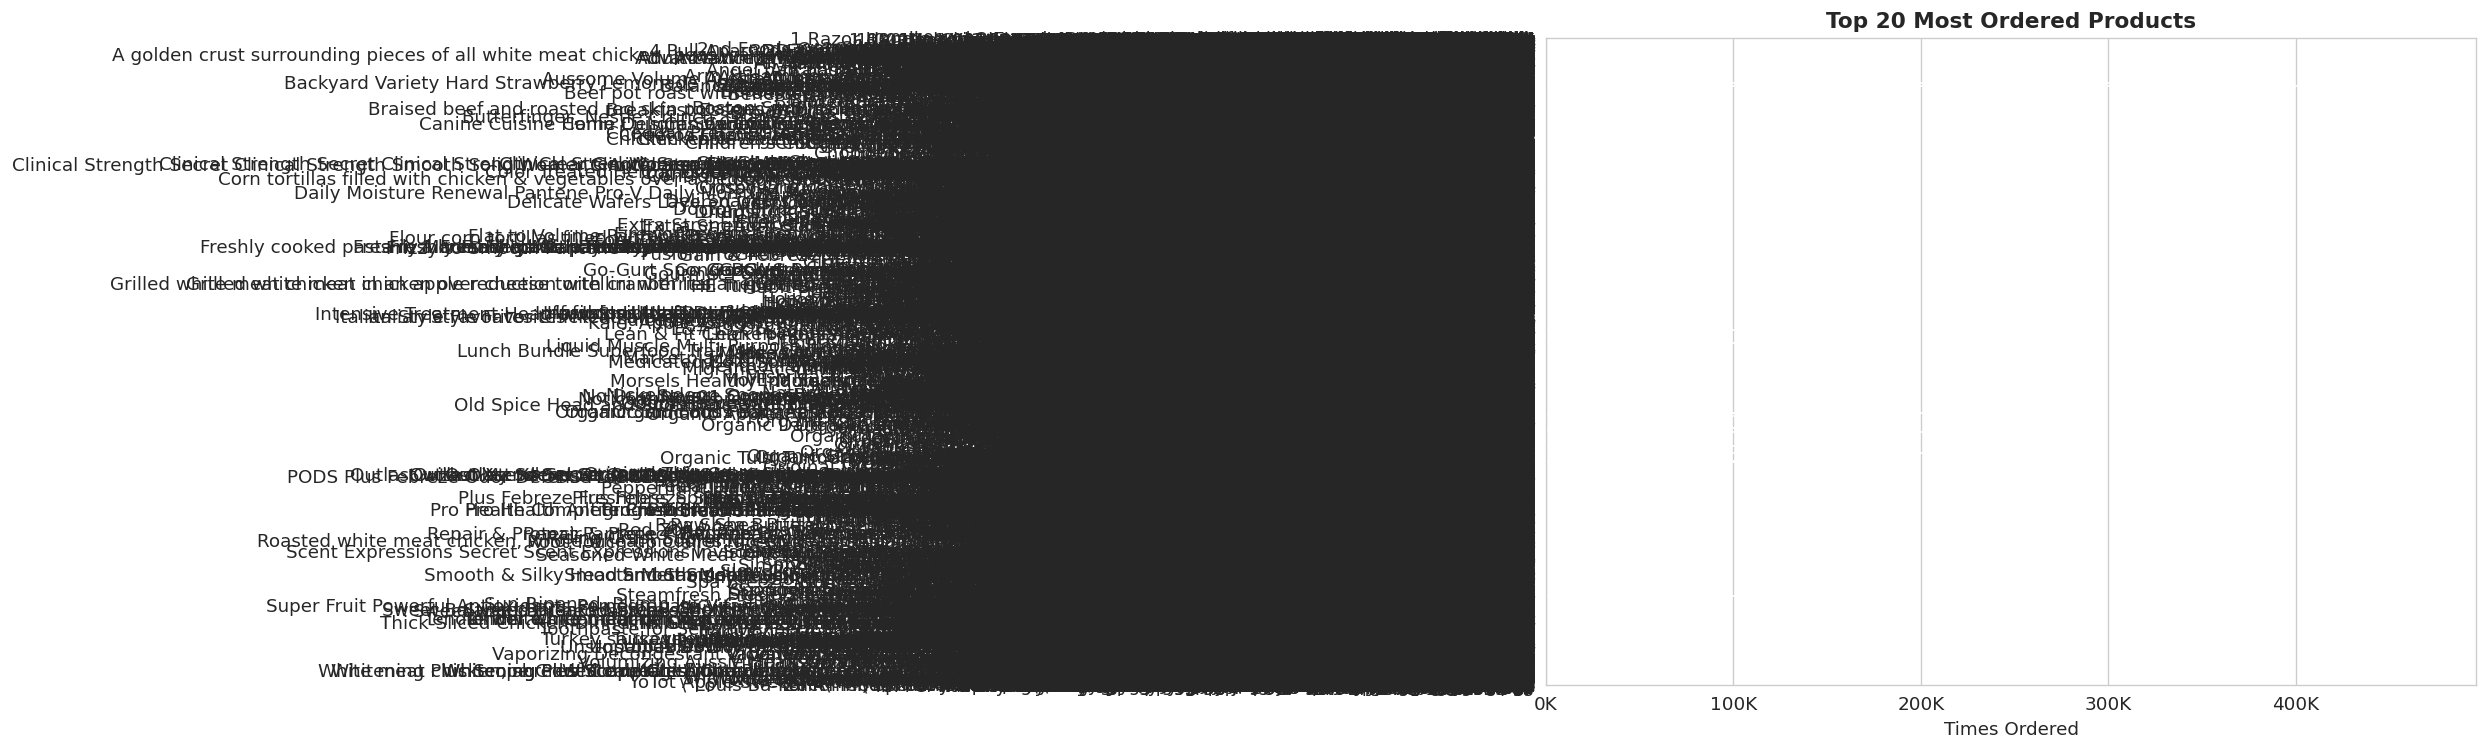

In [ ]:
# *** Top 20 Most Ordered Products (may take more than 3 mins to execute)
# --- Top 20 Most Ordered Products ---
top_products = df.groupby('product_name')['product_id'].count().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 9))
plt.barh(range(20), top_products.values, color=sns.color_palette('Greens_r', 20))
plt.yticks(range(20), top_products.index, fontsize=10)
plt.title('Top 20 Most Ordered Products', fontsize=13, fontweight='bold')
plt.xlabel('Times Ordered')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plot_top_products.png', bbox_inches='tight')
plt.show()

---
## PART 3: EDA — Customer Behavior

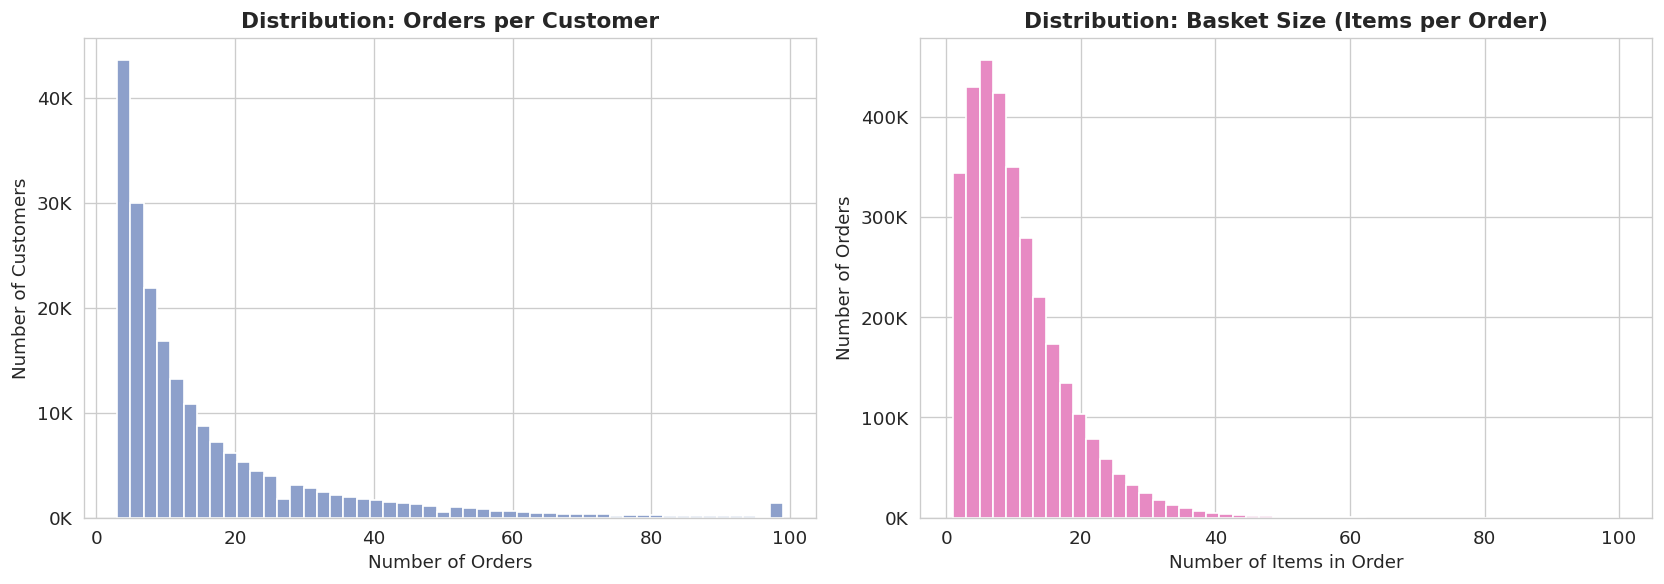

 Orders per customer  — median: 9, mean: 15.6, max: 99
 Basket size          — median: 8, mean: 10.1


In [ ]:
# *** Distribution: Number of Orders per Customer
orders_per_user = df.drop_duplicates('order_id').groupby('user_id')['order_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(orders_per_user, bins=50, color=sns.color_palette(PALETTE)[2], edgecolor='white')
axes[0].set_title('Distribution: Orders per Customer', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

# Basket size distribution
basket_size = df.groupby('order_id')['product_id'].count()
axes[1].hist(basket_size, bins=50, color=sns.color_palette(PALETTE)[3], edgecolor='white')
axes[1].set_title('Distribution: Basket Size (Items per Order)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Items in Order')
axes[1].set_ylabel('Number of Orders')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.savefig('plot_customer_distributions.png', bbox_inches='tight')
plt.show()

print(f' Orders per customer  — median: {orders_per_user.median():.0f}, mean: {orders_per_user.mean():.1f}, max: {orders_per_user.max()}')
print(f' Basket size          — median: {basket_size.median():.0f}, mean: {basket_size.mean():.1f}')


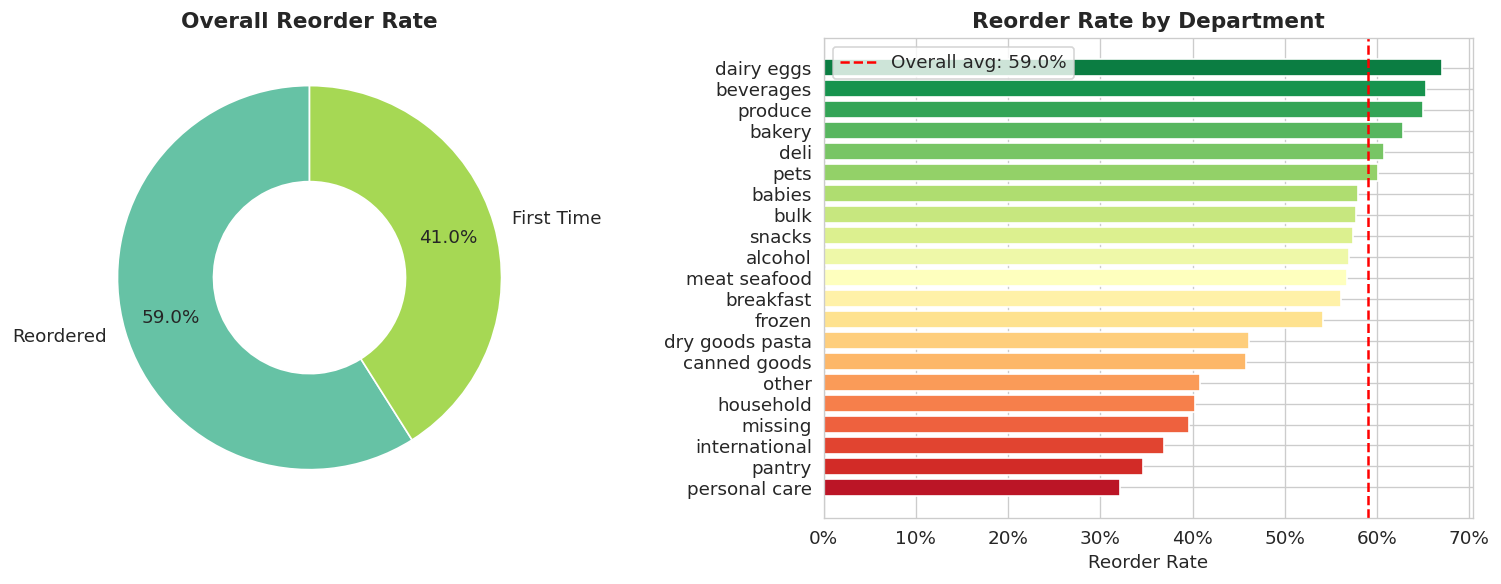

 Overall reorder rate: 59.0%


In [ ]:
# *** Overall Reorder Rate
overall_reorder_rate = df['reordered'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie([overall_reorder_rate, 1 - overall_reorder_rate],
            labels=['Reordered', 'First Time'],
            autopct='%1.1f%%',
            colors=[sns.color_palette(PALETTE)[0], sns.color_palette(PALETTE)[4]],
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.5))
axes[0].set_title(f'Overall Reorder Rate', fontsize=13, fontweight='bold')

# Reorder rate by department
dept_reorder = df.groupby('department')['reordered'].mean().sort_values(ascending=False)
axes[1].barh(dept_reorder.index[::-1], dept_reorder.values[::-1],
             color=sns.color_palette('RdYlGn', len(dept_reorder)))
axes[1].axvline(overall_reorder_rate, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall avg: {overall_reorder_rate:.1%}')
axes[1].set_title('Reorder Rate by Department', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Reorder Rate')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_reorder_analysis.png', bbox_inches='tight')
plt.show()

print(f' Overall reorder rate: {overall_reorder_rate:.1%}')

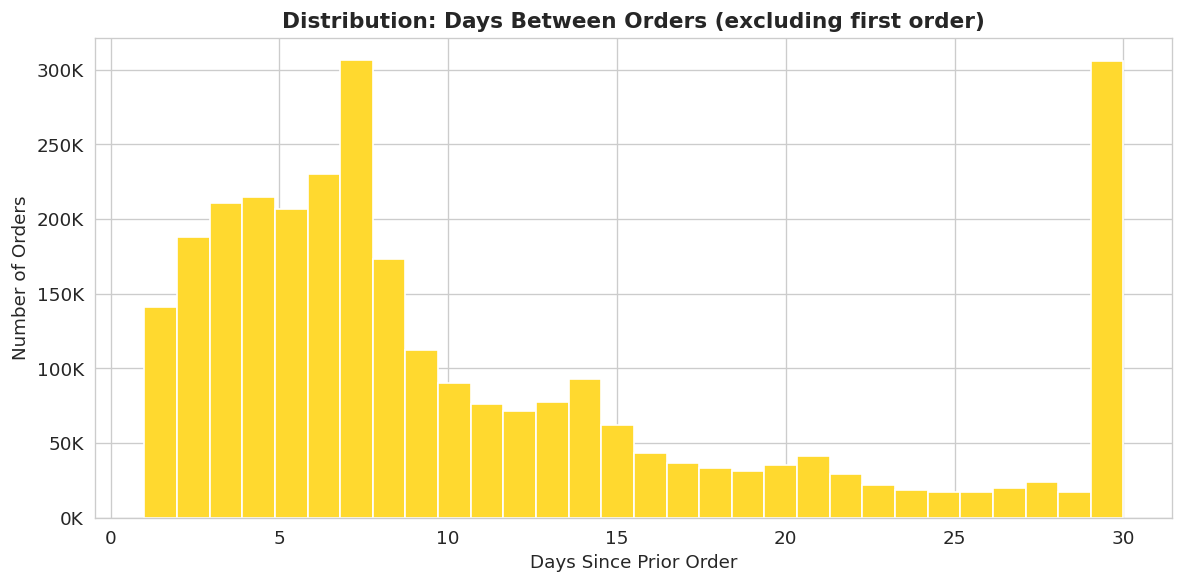

 Median days between orders: 7 days
 Mean days between orders  : 10.9 days


In [ ]:
# *** Days Since Prior Order Distribution
# Note: 0 = first order (filled from NaN), exclude for this chart
days_dist = df.drop_duplicates('order_id')['days_since_prior_order']
days_dist_nonzero = days_dist[days_dist > 0]

plt.figure(figsize=(10, 5))
plt.hist(days_dist_nonzero, bins=30, color=sns.color_palette(PALETTE)[5], edgecolor='white')
plt.title('Distribution: Days Between Orders (excluding first order)', fontsize=13, fontweight='bold')
plt.xlabel('Days Since Prior Order')
plt.ylabel('Number of Orders')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.tight_layout()
plt.savefig('plot_days_between_orders.png', bbox_inches='tight')
plt.show()

print(f' Median days between orders: {days_dist_nonzero.median():.0f} days')
print(f' Mean days between orders  : {days_dist_nonzero.mean():.1f} days')

---
## PART 4: Feature Engineering — User-Level Features

Build a `user_features` table aggregated at the `user_id` level.  
Each row = one customer, with features summarizing their historical behavior.

In [7]:
def reduce_mem_usage(df, verbose=True):
    """Downcast numeric columns to reduce memory footprint."""
    start_mem = df.memory_usage(deep=True).sum() / 1e6
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        col_min, col_max = df[col].min(), df[col].max()
        if str(df[col].dtype).startswith('int'):
            if col_min >= np.iinfo(np.int8).min and col_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        else:
            df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1e6
    if verbose:
        print(f'Memory reduced from {start_mem:.1f} MB → {end_mem:.1f} MB ({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')
    return df

print(' Helper function defined.')

 Helper function defined.


In [8]:
# Build order-level summary first (deduplicated)
orders_dedup = df.drop_duplicates(subset='order_id').copy()

# Basket size per order
basket = df.groupby('order_id')['product_id'].count().reset_index()
basket.columns = ['order_id', 'basket_size']

orders_dedup = orders_dedup.merge(basket, on='order_id', how='left')

print(f'Orders table shape: {orders_dedup.shape}')
orders_dedup[['order_id', 'user_id', 'basket_size', 'days_since_prior_order']].head()

NameError: name 'df' is not defined

In [ ]:
# *** USER FEATURES (may take more than 3 minutes to execute)

print('Building user features...')

# 1. Core order stats
uf = orders_dedup.groupby('user_id').agg(
    user_total_orders        = ('order_id', 'count'),
    user_avg_basket_size     = ('basket_size', 'mean'),
    user_max_basket_size     = ('basket_size', 'max'),
    user_min_basket_size     = ('basket_size', 'min'),
    user_avg_days_between    = ('days_since_prior_order', lambda x: x[x > 0].mean()),  # exclude first order (=0)
    user_median_days_between = ('days_since_prior_order', lambda x: x[x > 0].median()),
    user_std_days_between    = ('days_since_prior_order', lambda x: x[x > 0].std()),
    # Temporal habits
    user_peak_hour           = ('order_hour_of_day', lambda x: x.value_counts().idxmax()),
    user_peak_dow            = ('order_dow', lambda x: x.value_counts().idxmax()),
    user_avg_hour            = ('order_hour_of_day', 'mean'),
    user_avg_dow             = ('order_dow', 'mean'),
).reset_index()

# 2. Reorder rate per user
reorder_stats = df.groupby('user_id').agg(
    user_reorder_rate        = ('reordered', 'mean'),
    user_total_items_bought  = ('product_id', 'count'),
    user_unique_products     = ('product_id', 'nunique'),
).reset_index()

uf = uf.merge(reorder_stats, on='user_id', how='left')

# 3. Derived features
uf['user_diversity_ratio'] = (uf['user_unique_products'] / uf['user_total_items_bought']).astype(np.float32)

# 4. Downcast memory
uf = reduce_mem_usage(uf)

print(f'\n user_features shape: {uf.shape}')
uf.head()

Building user features...
Memory reduced from 21.9 MB → 9.3 MB (57.5% reduction)

 user_features shape: (206209, 16)


,user_id,user_total_orders,user_avg_basket_size,user_max_basket_size,user_min_basket_size,user_avg_days_between,user_median_days_between,user_std_days_between,user_peak_hour,user_peak_dow,user_avg_hour,user_avg_dow,user_reorder_rate,user_total_items_bought,user_unique_products,user_diversity_ratio
0,1,10,5.900000,9,4,22.000000,20.5,6.279217,7,4,10.300000,2.500000,0.694915,59,18,0.305085
1,2,14,13.928572,26,5,15.230769,13.0,9.867064,10,2,10.571428,2.142857,0.476923,195,102,0.523077
2,3,12,7.333333,11,5,12.090909,11.0,5.375026,16,0,16.416666,1.083333,0.625000,88,33,0.375000
3,4,5,3.600000,7,2,18.333334,19.0,3.055050,13,5,12.600000,4.800000,0.055556,18,17,0.944444
4,5,4,9.250000,12,5,13.333333,11.0,4.932883,18,3,16.000000,1.750000,0.378378,37,23,0.621622


In [ ]:
# Quick stats on the features
uf.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
user_id,206209.000000,103105.000000,59527.555167,1.000000,51553.000000,103105.000000,154657.000000,206209.000000
user_total_orders,206209.000000,15.590270,16.654649,3.000000,5.000000,9.000000,19.000000,99.000000
user_avg_basket_size,206209.000000,9.951235,5.861808,1.000000,5.740741,8.933333,13.000000,70.250000
user_max_basket_size,206209.000000,17.652508,10.176176,1.000000,10.000000,16.000000,23.000000,100.000000
user_min_basket_size,206209.000000,4.294735,3.953049,1.000000,1.000000,3.000000,6.000000,51.000000
user_avg_days_between,206185.000000,15.404814,7.109001,1.000000,9.571428,14.722222,20.500000,30.000000
user_median_days_between,206185.000000,14.927140,8.666127,1.000000,7.000000,13.000000,21.500000,30.000000
user_std_days_between,205565.000000,7.279368,3.690078,0.000000,4.645787,7.671354,9.812529,20.506096
user_peak_hour,206209.000000,13.515075,3.918294,0.000000,10.000000,13.000000,16.000000,23.000000
user_peak_dow,206209.000000,2.553996,2.136871,0.000000,1.000000,2.000000,5.000000,6.000000


---
## PART 5: Visualize the User Features

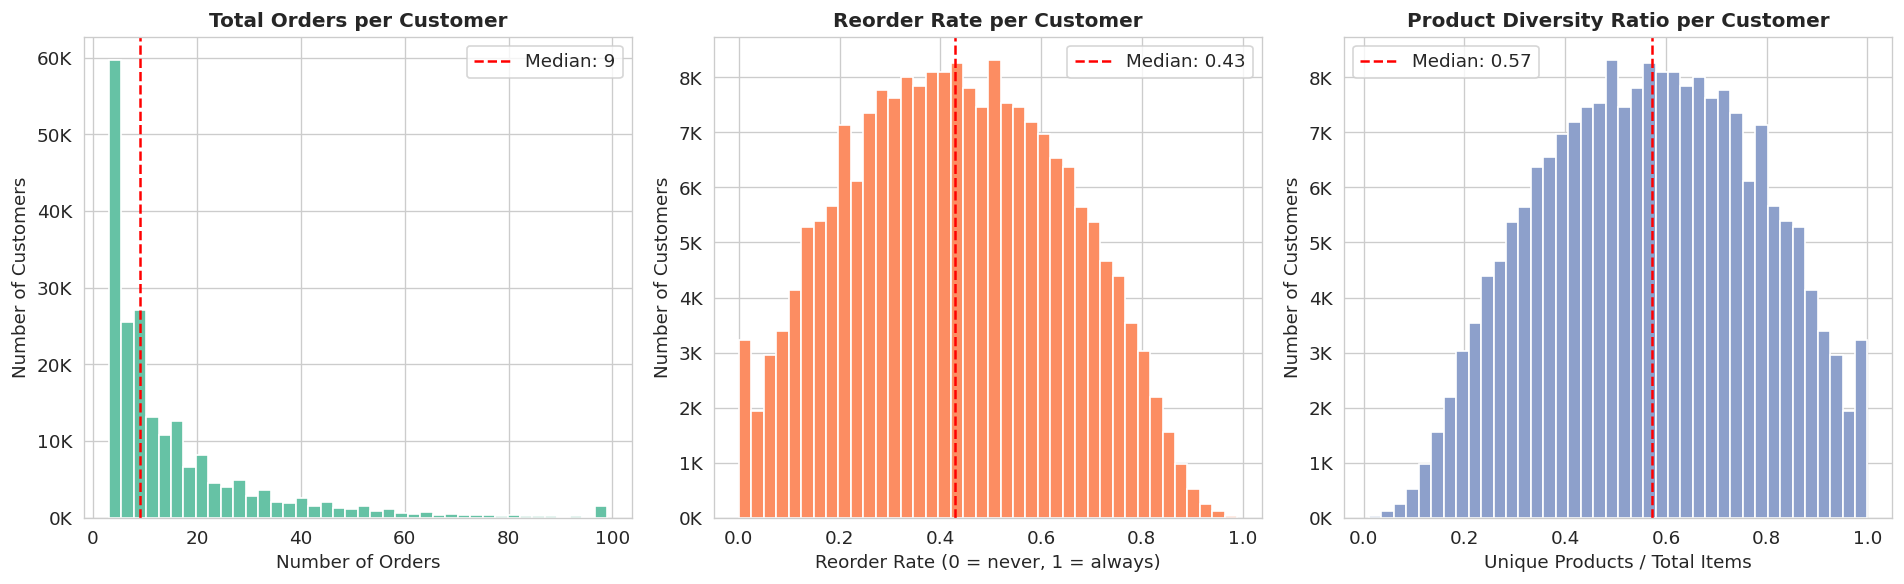

In [ ]:
#  *** User Segmentation by Reorder Rate
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total orders per user
axes[0].hist(uf['user_total_orders'], bins=40,
             color=sns.color_palette(PALETTE)[0], edgecolor='white')
axes[0].set_title('Total Orders per Customer', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[0].axvline(uf['user_total_orders'].median(), color='red',
                linestyle='--', label=f'Median: {uf["user_total_orders"].median():.0f}')
axes[0].legend()

# Reorder rate per user
axes[1].hist(uf['user_reorder_rate'].dropna(), bins=40,
             color=sns.color_palette(PALETTE)[1], edgecolor='white')
axes[1].set_title('Reorder Rate per Customer', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Reorder Rate (0 = never, 1 = always)')
axes[1].set_ylabel('Number of Customers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[1].axvline(uf['user_reorder_rate'].median(), color='red',
                linestyle='--', label=f'Median: {uf["user_reorder_rate"].median():.2f}')
axes[1].legend()

# Product diversity ratio
axes[2].hist(uf['user_diversity_ratio'].dropna(), bins=40,
             color=sns.color_palette(PALETTE)[2], edgecolor='white')
axes[2].set_title('Product Diversity Ratio per Customer', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Unique Products / Total Items')
axes[2].set_ylabel('Number of Customers')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[2].axvline(uf['user_diversity_ratio'].median(), color='red',
                linestyle='--', label=f'Median: {uf["user_diversity_ratio"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot_user_features.png', bbox_inches='tight')
plt.show()

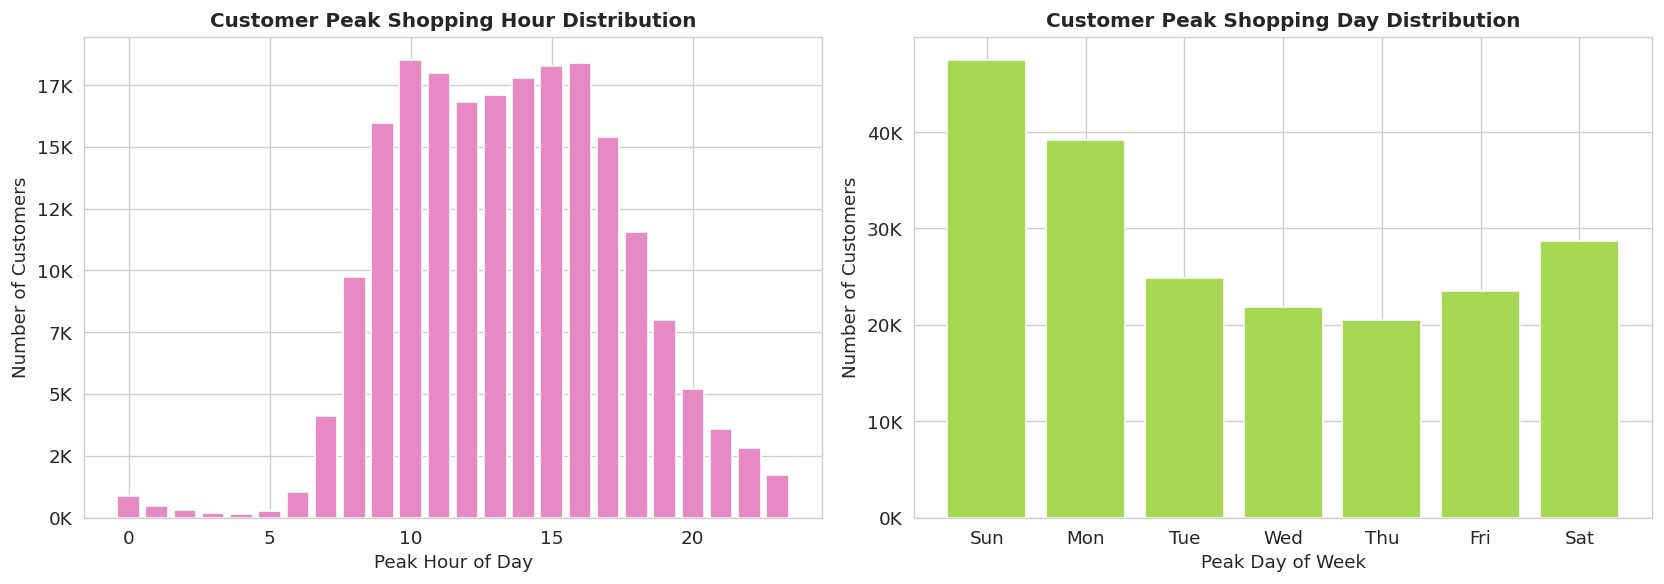

In [ ]:
# *** Shopping Habits: Peak Hour & Peak Day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peak hour distribution across users
peak_hour_dist = uf['user_peak_hour'].value_counts().sort_index()
axes[0].bar(peak_hour_dist.index, peak_hour_dist.values,
            color=sns.color_palette(PALETTE)[3])
axes[0].set_title('Customer Peak Shopping Hour Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Peak Hour of Day')
axes[0].set_ylabel('Number of Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

# Peak day distribution across users
peak_dow_dist = uf['user_peak_dow'].value_counts().sort_index()
dow_labels_short = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
axes[1].bar([dow_labels_short[i] for i in peak_dow_dist.index], peak_dow_dist.values,
            color=sns.color_palette(PALETTE)[4])
axes[1].set_title('Customer Peak Shopping Day Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Peak Day of Week')
axes[1].set_ylabel('Number of Customers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.savefig('plot_user_habits.png', bbox_inches='tight')
plt.show()

In [ ]:
# *** Correlation Heatmap of User Features
corr_cols = [
    'user_total_orders', 'user_avg_basket_size',
    'user_avg_days_between', 'user_reorder_rate',
    'user_unique_products', 'user_diversity_ratio'
]

corr = uf[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — User Features', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot_feature_correlation.png', bbox_inches='tight')
plt.show()

---
## PART 6: Export User Features

In [ ]:
OUTPUT_PATH = DATA_PATH + 'user_features.parquet'
uf.to_parquet(OUTPUT_PATH, index=False)

print(f'Saved: {OUTPUT_PATH}')
print(f'   Shape : {uf.shape[0]:,} users × {uf.shape[1]} features')
print(f'   Memory: {uf.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Feature list:')
for col in uf.columns:
    print(f'   {col} ({uf[col].dtype})')

Saved: /content/drive/MyDrive/Instacart_Project/user_features.parquet
   Shape : 206,209 users × 16 features
   Memory: 9.3 MB

Feature list:
   user_id (int32)
   user_total_orders (int8)
   user_avg_basket_size (float32)
   user_max_basket_size (int8)
   user_min_basket_size (int8)
   user_avg_days_between (float32)
   user_median_days_between (float32)
   user_std_days_between (float32)
   user_peak_hour (int8)
   user_peak_dow (int8)
   user_avg_hour (float32)
   user_avg_dow (float32)
   user_reorder_rate (float32)
   user_total_items_bought (int16)
   user_unique_products (int16)
   user_diversity_ratio (float32)


---
##  SUMMARY
### EDA Key Findings
| Insight | Detail |
|---|---|
| Peak shopping hours | 9 AM – 4 PM |
| Busiest days | Sunday & Monday |
| Overall reorder rate | ~59% |
| Median basket size | ~8 items/order |
| Top department | Produce |

### User Features Built
| Feature | Description |
|---|---|
| `user_total_orders` | Total historical orders per user |
| `user_avg_basket_size` | Average number of items per order |
| `user_max/min_basket_size` | Range of basket sizes |
| `user_avg_days_between` | Average days between orders |
| `user_median_days_between` | Median days between orders |
| `user_std_days_between` | Regularity of shopping cadence |
| `user_peak_hour` | Most frequent shopping hour |
| `user_peak_dow` | Most frequent shopping day |
| `user_avg_hour` | Average shopping hour |
| `user_avg_dow` | Average shopping day of week |
| `user_reorder_rate` | Fraction of items that are reorders |
| `user_total_items_bought` | Total items purchased |
| `user_unique_products` | Number of distinct products bought |
| `user_diversity_ratio` | unique_products / total_items |

> **Next step:** Merge `user_features.parquet` with product and user-product features for the full feature matrix before modeling.